# Column Detection — Test Notebook

Everything comes from `agent.py` — one import.  
Results are persisted automatically to `detections.db` (SQLite).

**Kernel**: `yolo` conda environment

In [ ]:
import sys, json, importlib
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path(".").resolve()))
import agent
print("agent.py loaded OK")

## 1 — Environment check

In [25]:
print(json.dumps(agent.get_status(), indent=2))

{
  "ollama": "ok",
  "model": "qwen3-vl:8b",
  "available": [
    "qwen3.5:9b",
    "llama3.1:8b",
    "qwen3-vl:8b",
    "deepseek-coder-v2:16b-lite-instruct-q8_0",
    "qwen3-coder:30b-a3b-q4_K_M",
    "minimax-m2.5:cloud",
    "moondream:latest"
  ]
}


## 2 — Ground-truth reference images

Drop any new column image into `ground_truth/columns/` and call `references_reload()`.  
Filenames are matched to shapes automatically (keywords: square/rect/round/circle/i_beam/i_col).

In [26]:
# Show which reference images are currently loaded (one per shape, largest file wins)
refs = agent._load_references()
print(f"Loaded {len(refs)} reference image(s):")
for shape, b64 in refs:
    print(f"  {shape:12s}  ({len(b64)} bytes b64)")

Loaded 4 reference image(s):
  circle        (42984 bytes b64)
  i_beam        (4372 bytes b64)
  rectangle     (3628 bytes b64)
  square        (3292 bytes b64)


In [27]:
# After adding new files to ground_truth/columns/, reload without restarting the kernel
loaded = agent.references_reload()
print("Shapes now loaded:", loaded)

Shapes now loaded: ['circle', 'i_beam', 'rectangle', 'square']


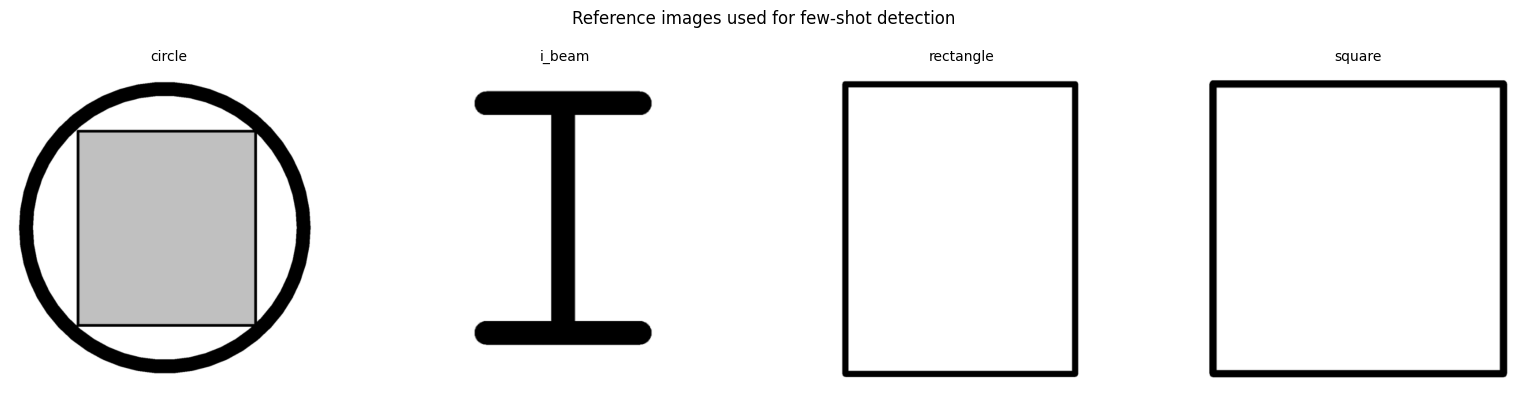

In [28]:
# Visualise all reference images
refs = agent._load_references()
import io, base64
fig, axes = plt.subplots(1, len(refs), figsize=(4 * len(refs), 4))
if len(refs) == 1: axes = [axes]
for ax, (shape, b64) in zip(axes, refs):
    img = Image.open(io.BytesIO(base64.b64decode(b64)))
    ax.imshow(img, cmap='gray')
    ax.set_title(shape, fontsize=10)
    ax.axis('off')
plt.suptitle("Reference images used for few-shot detection")
plt.tight_layout(); plt.show()

## 3 — Detect on a single ground-truth image

In [29]:
gt_images = agent.get_ground_truth_images()
for p in gt_images:
    print(Path(p).name)

i_column.png
i_sqau_column.png
i_squa_column_with_footing.png
rect_column.png
rect_column2.png
round_column.png
round_column_with_footing.png
round_squ_column.png
squ_round_column.png
squ_round_column2.png
squa_round_column_with_footing.png
square_column1.png
square_column3.png


In [30]:
test_image = gt_images[0]   # ← change index to test others
result = agent.detect_file(test_image, verbose=True)

print(f"\nrun_id : {result['run_id']}")
print(f"columns: {result['total_columns']}")
print(json.dumps(result['stats'], indent=2))

  Image: 306×415 px  |  Tiles: 1
  Tile 1/1  offset=(0,0)
[DEBUG tile 0] raw response:




run_id : 50069bcd-c60f-4894-a3d3-6e1b6b67fdee
columns: 0
{
  "by_shape": {},
  "avg_confidence": 0.0,
  "tiles": 1
}


In [31]:
for det in result['detections']:
    print(f"  [{det['id']}] {det['shape']:12s}  conf={det['confidence']:.0%}  "
          f"bbox={[int(v) for v in det['bbox_page']]}  {det['notes'][:60]}")

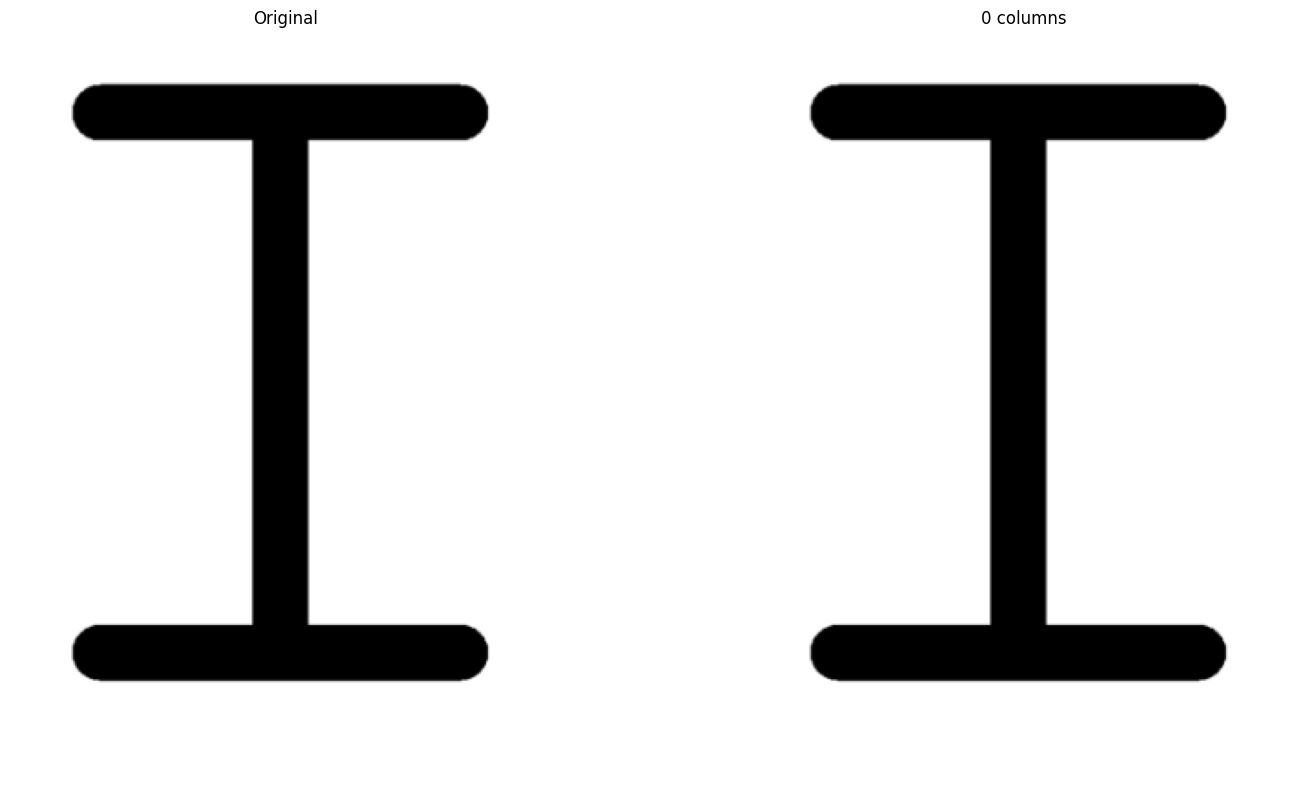

In [32]:
orig      = Image.open(test_image).convert("RGB")
annotated = agent.draw_detections(orig, result['detections'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(orig);       axes[0].set_title("Original");                          axes[0].axis('off')
axes[1].imshow(annotated);  axes[1].set_title(f"{result['total_columns']} columns"); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 4 — Detect columns in a PDF

In [ ]:
importlib.reload(agent)

PDF_PATH = "/home/jiezhi/Documents/floor-plan-pdf/TGCH-TD-S-200-L3-00.pdf"   # ← change this
PAGE_NUM = 0

if not Path(PDF_PATH).exists():
    print(f"PDF not found: {PDF_PATH}")
else:
    result = agent.detect_file(PDF_PATH, page_num=PAGE_NUM, verbose=False)
    print(f"run_id  : {result['run_id']}")
    print(f"columns : {result['total_columns']}")
    print(json.dumps(result['stats'], indent=2))

In [ ]:
# Render the PDF page and draw bounding boxes inline
import fitz  # PyMuPDF

if "error" not in result:
    doc = fitz.open(PDF_PATH)
    pix = doc[PAGE_NUM].get_pixmap(matrix=fitz.Matrix(agent.RENDER_DPI/72, agent.RENDER_DPI/72),
                                   colorspace=fitz.csRGB)
    doc.close()
    orig      = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
    annotated = agent.draw_detections(orig, result["detections"])

    fig, axes = plt.subplots(1, 2, figsize=(24, 14))
    axes[0].imshow(orig)
    axes[0].set_title(f"Original — page {PAGE_NUM}", fontsize=12)
    axes[0].axis("off")
    axes[1].imshow(annotated)
    axes[1].set_title(f"{result['total_columns']} columns detected", fontsize=12)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    # Per-detection table
    if result["detections"]:
        print(f"\n{'id':>4}  {'shape':12}  {'conf':>6}  {'bbox (page px)':30}  notes")
        print("-" * 85)
        for d in result["detections"]:
            bb = [int(v) for v in d["bbox_page"]]
            print(f"{d['id']:>4}  {d['shape']:12}  {d['confidence']:.0%}  {str(bb):30}  {d['notes'][:40]}")

## 5 — Query the SQLite memory

In [17]:
# Overall stats
print(json.dumps(agent.memory_stats(), indent=2))

{
  "total_runs": 2,
  "total_columns": 0,
  "by_shape": {},
  "avg_confidence": 0.0
}


In [18]:
# List recent runs (copy a run_id from here to use in memory_clear below)
runs = agent.memory_runs(limit=10)
print(f"{'run_id':>38}  {'file':<30} {'page':>5} {'cols':>5}  timestamp")
print("-" * 95)
for r in runs:
    print(f"{r['run_id']:>38}  {Path(r['file_path']).name:<30} "
          f"{r['page_num']:>5} {r['total_cols']:>5}  {r['timestamp'][:19]}")

                                run_id  file                            page  cols  timestamp
-----------------------------------------------------------------------------------------------
  00c7409f-7c71-4d22-b4c4-062b2cea74cb  TGCH-TD-S-200-L3-00.pdf            0     0  2026-03-25T19:38:18
  2984d85d-936d-4543-ab6d-51067b5ad23f  i_column.png                       0     0  2026-03-25T19:09:23


In [19]:
# Search: all circle columns with confidence >= 80%
rows = agent.memory_search(shape="circle", min_confidence=0.8)
print(f"Found {len(rows)} circle columns with conf >= 80%")
for r in rows[:10]:
    print(f"  conf={r['confidence']:.0%}  file={Path(r['file_path']).name}  notes={r['notes'][:50]}")

Found 0 circle columns with conf >= 80%


## 6 — Clear memory

Use this to remove false positives or contaminated runs.

In [ ]:
# Delete one specific run by run_id (paste the run_id from Section 5 above)
RUN_TO_DELETE = "paste-run-id-here"

result = agent.memory_clear(run_id=RUN_TO_DELETE)
print(f"Deleted: {result}")

In [ ]:
# ⚠️  Wipe ALL memory — uncomment and run deliberately
# result = agent.memory_clear()
# print(f"Cleared: {result}")

## 7 — Agentic Q&A

In [ ]:
session = agent.AgentSession()
print(session.ask("Check the status and list available ground-truth images."))

In [ ]:
print(session.ask("Run detection on the first ground-truth image. What shapes were found?"))

In [ ]:
print(session.ask("Search memory for all circle columns with confidence above 80%."))